# Tugas 2 | Crawling Berita

Kode ini dibuat untuk melakukan web crawling berita dari situs Detik.com pada kategori Olahraga dan Pendidikan. Proses crawling dimulai dari tanggal *31 Desember 2024* dan berjalan mundur hingga jumlah berita yang diambil mencapai *100 berita*. Dari setiap berita yang ditemukan, program mengambil **judul, link, kategori, tanggal, dan isi berita**. Seluruh hasil kemudian disimpan ke dalam file CSV sehingga dapat digunakan untuk analisis lebih lanjut.

berikut Code Crawling nya:

## Crawling berita dari portal detik.com


### Import Library

In [12]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
from datetime import datetime, timedelta

### Fungsi crawling

Parameter:
- limit  : jumlah maksimum berita yang ingin diambil
- tahun  : tahun berita yang ingin dicrawl (default 2024)

Return:
- DataFrame berisi judul, link, kategori, tanggal, dan isi berita

In [2]:
def crawl_detik(limit_per_kategori=50, tahun=2024):
    # URL dasar berdasarkan kategori
    base_urls = {
        "Olahraga": "https://sport.detik.com/indeks",
        "Pendidikan": "https://www.detik.com/edu/indeks"
    }

    hasil = []  # list untuk menyimpan hasil crawl
    counter = {kategori: 0 for kategori in base_urls}  # hitung per kategori

    # header untuk menyamar sebagai browser
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                      "AppleWebKit/537.36 (KHTML, like Gecko) "
                      "Chrome/126.0.0.0 Safari/537.36"
    }

    # mulai dari tanggal 31 Desember tahun yang ditentukan
    tgl = datetime(tahun, 12, 31)

    # loop sampai semua kategori mencapai limit
    while not all(c >= limit_per_kategori for c in counter.values()) and tgl.year == tahun:
        tgl_str = tgl.strftime("%Y/%m/%d")
        tgl_csv = tgl.strftime("%Y-%m-%d")

        for kategori, base_url in base_urls.items():
            if counter[kategori] >= limit_per_kategori:
                continue  # skip kalau kategori sudah cukup

            url = f"{base_url}?date={tgl_str}"
            print(f"🔎 Crawling {kategori} {tgl_str} -> {url}")

            try:
                r = requests.get(url, headers=headers, timeout=10)
                r.raise_for_status()
                soup = BeautifulSoup(r.text, "html.parser")

                items = soup.find_all("article")
                if not items:
                    continue

                for item in items:
                    if counter[kategori] >= limit_per_kategori:
                        break

                    judul_tag = item.find("h3")
                    link_tag = item.find("a")

                    if judul_tag and link_tag:
                        judul = judul_tag.get_text(strip=True)
                        link = link_tag["href"]

                        isi = ""
                        try:
                            r2 = requests.get(link, headers=headers, timeout=10)
                            r2.raise_for_status()
                            soup2 = BeautifulSoup(r2.text, "html.parser")
                            content = soup2.find("div", class_="detail__body-text")
                            if content:
                                isi = " ".join([p.get_text(strip=True) for p in content.find_all("p")])
                        except Exception:
                            isi = "⚠️ Error ambil isi"

                        hasil.append({
                            "Judul Berita": judul,
                            "Link": link,
                            "Kategori": kategori,
                            "Tanggal": tgl_csv,
                            "Isi Berita": isi
                        })
                        counter[kategori] += 1
                        print(f"✅ Disimpan {kategori} ({counter[kategori]}): {judul}")

            except Exception as e:
                print(f"⚠️ Gagal membuka {url}: {e}")

        tgl -= timedelta(days=1)

    df = pd.DataFrame(hasil)  
    df["Tanggal"] = df["Tanggal"].astype(str)
    return df


# Eksekusi utama
data = crawl_detik(limit_per_kategori=50, tahun=2024)

print("\nTotal berita berhasil dicrawl:", len(data))
print("Rincian per kategori:")
print(data["Kategori"].value_counts())

data.to_csv("detik_berita_2024.csv", index=False, encoding="utf-8-sig")
print("✅ Hasil disimpan ke detik_berita_2024.csv")


🔎 Crawling Olahraga 2024/12/31 -> https://sport.detik.com/indeks?date=2024/12/31
✅ Disimpan Olahraga (1): Marcus Gideon ke Ganda Pratama : Enggak Bisa Santai Kalau Mau Jago
✅ Disimpan Olahraga (2): Megawati Tampil Gemilang, Red Sparks Gebuk IBK Altos 3-0
✅ Disimpan Olahraga (3): Punya Tim & Semangat Baru, Jakarta Pertamina Enduro Siap Taklukkan Proliga
✅ Disimpan Olahraga (4): Jakarta Pertamina Enduro Tak Mau Lagi Cuma Gaspol di Awal Proliga
✅ Disimpan Olahraga (5): Ducati ke Honda: Bangun Motor Butuh Waktu, Tak Cuma Semalam
✅ Disimpan Olahraga (6): Herry IP ke Malaysia: Tinggal Tunggu Draf Kontrak
✅ Disimpan Olahraga (7): Tinggalkan Indonesia, Herry IP Pastikan Siap Latih Malaysia
🔎 Crawling Pendidikan 2024/12/31 -> https://www.detik.com/edu/indeks?date=2024/12/31
✅ Disimpan Pendidikan (1): 'UN' Sistem Baru Akan Diadakan Kemendikdasmen di 2026, Tulis Pendapatmu di POV!
✅ Disimpan Pendidikan (2): Penemuan Bangkai Paus Paling Langka di Dunia, Ilmuwan Ungkap Fakta Ini
✅ Disimpan Pendidik

## EDA (Exploratory Data Analysis)

Setelah mendapatkan dataset nya lalu kita lakukan EDA, Tujuannya supaya kita bisa paham dulu bentuk dan karakteristik data mentah hasil crawling sebelum masuk ke tahap preprocessing.

membaca dari dataset langsung agar tidak bergantung ke cell diatas "df"

### Import Library

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

### Melakukan EDA

Panggil dataset dari file nya langsung agar tidak bergantung cell diatas 'df'

In [14]:
df = pd.read_csv("detik_berita_2024.csv")

- Menampilkan beberapa baris awal dataset

In [15]:
print(df.head())

                                        Judul Berita  \
0  Marcus Gideon ke Ganda Pratama : Enggak Bisa S...   
1  Megawati Tampil Gemilang, Red Sparks Gebuk IBK...   
2  Punya Tim & Semangat Baru, Jakarta Pertamina E...   
3  Jakarta Pertamina Enduro Tak Mau Lagi Cuma Gas...   
4  Ducati ke Honda: Bangun Motor Butuh Waktu, Tak...   

                                                Link  Kategori     Tanggal  \
0  https://sport.detik.com/raket/d-7712417/marcus...  Olahraga  2024-12-31   
1  https://sport.detik.com/sport-lain/d-7712305/m...  Olahraga  2024-12-31   
2  https://sport.detik.com/sport-lain/d-7712206/p...  Olahraga  2024-12-31   
3  https://sport.detik.com/sport-lain/d-7712029/j...  Olahraga  2024-12-31   
4  https://sport.detik.com/moto-gp/d-7711970/duca...  Olahraga  2024-12-31   

                                          Isi Berita  
0  Marcus Fernaldi Gideonhadir di PelatnasPBSI. K...  
1  Megawati Hangestri PertiwimembawaRed Sparksmer...  
2  Tahun ini, tim Pertamina J

- info kolom dataset

In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Judul Berita  100 non-null    object
 1   Link          100 non-null    object
 2   Kategori      100 non-null    object
 3   Tanggal       100 non-null    object
 4   Isi Berita    96 non-null     object
dtypes: object(5)
memory usage: 4.0+ KB
None


- cek missig values

In [19]:
print(df.isnull().sum())

Judul Berita    0
Link            0
Kategori        0
Tanggal         0
Isi Berita      4
dtype: int64


- Distribusi panjang teks (jumlah kata per berita)

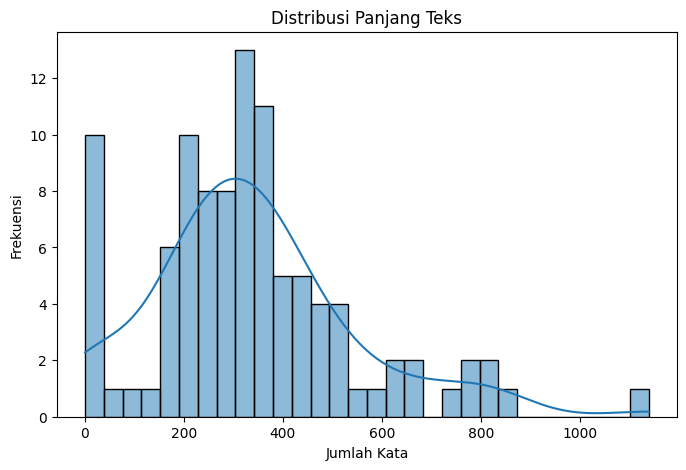

In [22]:
df['text_length'] = df['Isi Berita'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=30, kde=True)
plt.title("Distribusi Panjang Teks")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.show()

- Wordcloud

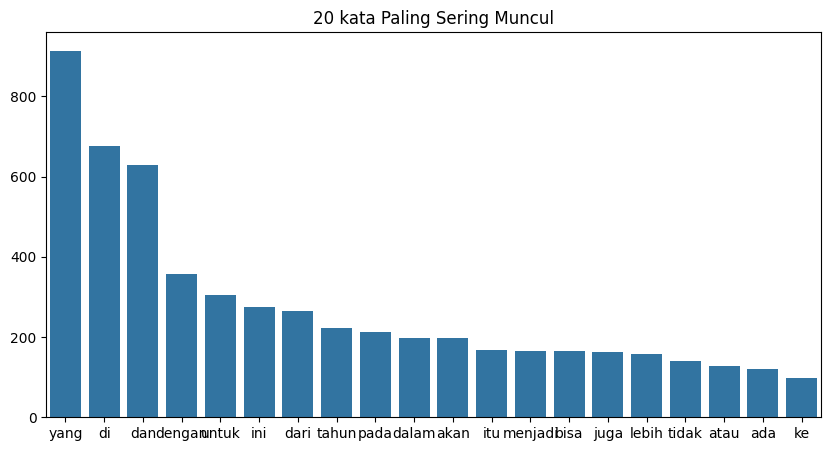

In [25]:
all_words = " ".join(df['Isi Berita'].astype(str)).split()
counter = Counter(all_words)
common_words = counter.most_common(20)

words, counts = zip(*common_words)

plt.figure(figsize=(10,5))
sns.barplot(x=list(words), y=list(counts))
plt.title("20 kata Paling Sering Muncul")
plt.show()

- Distribusi kelas

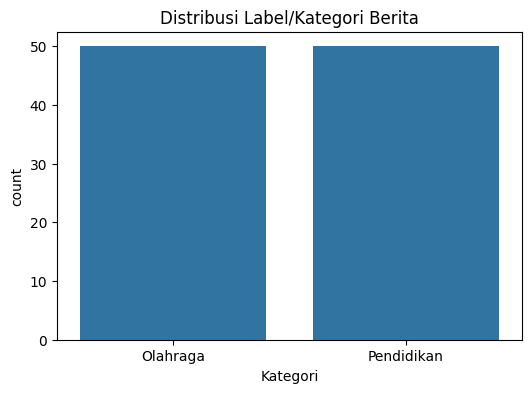

In [26]:
if 'Kategori' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Kategori', data=df)
    plt.title("Distribusi Label/Kategori Berita")
    plt.show()